In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("processed_data.csv")

data.head()

,age,generation,netustm,slprl,ctrlife,fltdpr,happy,health,fltlnl,fltsd,gndr,uemp3m,inprdsc,usage_level,depression_level
0,21,Gen Z,570.0,3.0,8.0,2.0,9.0,2.0,3.0,2.0,2.0,2,4,Very Heavy (6h+),Mild
1,30,Millennial,240.0,1.0,6.0,2.0,5.0,3.0,1.0,2.0,2.0,2,4,Heavy (3-6h),Mild
2,41,Millennial,360.0,2.0,8.0,1.0,10.0,1.0,1.0,2.0,1.0,2,6,Heavy (3-6h),Not Depressed
3,26,Gen Z,600.0,1.0,6.0,1.0,8.0,1.0,1.0,1.0,1.0,1,4,Very Heavy (6h+),Not Depressed
4,42,Millennial,180.0,2.0,6.0,2.0,5.0,2.0,1.0,2.0,1.0,1,4,Moderate (1-3h),Mild


In [36]:
print("Shape:", data.shape)
print()
data.info()

Shape: (14965, 15)

<class 'pandas.DataFrame'>
RangeIndex: 14965 entries, 0 to 14964
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               14965 non-null  int64  
 1   generation        14965 non-null  str    
 2   netustm           14965 non-null  float64
 3   slprl             14965 non-null  float64
 4   ctrlife           14965 non-null  float64
 5   fltdpr            14965 non-null  float64
 6   happy             14965 non-null  float64
 7   health            14965 non-null  float64
 8   fltlnl            14965 non-null  float64
 9   fltsd             14965 non-null  float64
 10  gndr              14965 non-null  float64
 11  uemp3m            14965 non-null  int64  
 12  inprdsc           14965 non-null  int64  
 13  usage_level       14965 non-null  str    
 14  depression_level  14965 non-null  str    
dtypes: float64(9), int64(3), str(3)
memory usage: 1.7 MB


In [37]:
data["uemp3m"] = data["uemp3m"].replace([7, 8, 9], np.nan)
data["inprdsc"] = data["inprdsc"].replace([77, 88, 99], np.nan)

print(data[["uemp3m", "inprdsc"]].isna().sum())

uemp3m     109
inprdsc     59
dtype: int64


In [38]:
before = len(data)

data = data.dropna(subset=["uemp3m", "inprdsc"]).reset_index(drop=True)

print("Rows removed:", before - len(data))
print("New shape:", data.shape)

Rows removed: 165
New shape: (14800, 15)


In [39]:
data["depressive_feelings"] = (data["fltdpr"] >= 2).astype(int)

print(data["depressive_feelings"].value_counts())
print()
print(data["depressive_feelings"].value_counts(normalize=True) * 100)

depressive_feelings
0    9719
1    5081
Name: count, dtype: int64

depressive_feelings
0    65.668919
1    34.331081
Name: proportion, dtype: float64


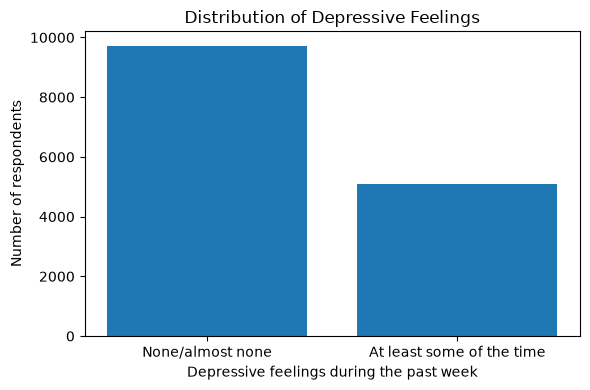

In [40]:
target_counts = data["depressive_feelings"].value_counts().sort_index()

plt.figure(figsize=(6, 4))

plt.bar(
    ["None/almost none", "At least some of the time"],
    target_counts.values
)

plt.title("Distribution of Depressive Feelings")
plt.xlabel("Depressive feelings during the past week")
plt.ylabel("Number of respondents")

plt.tight_layout()
plt.show()

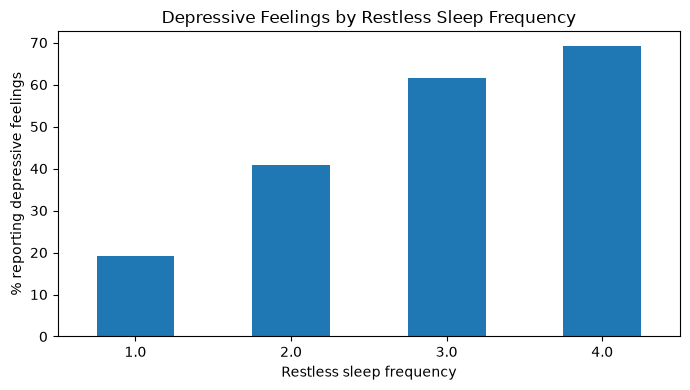

In [41]:
sleep_relation = (
    data.groupby("slprl")["depressive_feelings"]
    .mean() * 100
)

plt.figure(figsize=(7, 4))
sleep_relation.plot(kind="bar")

plt.title("Depressive Feelings by Restless Sleep Frequency")
plt.xlabel("Restless sleep frequency")
plt.ylabel("% reporting depressive feelings")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

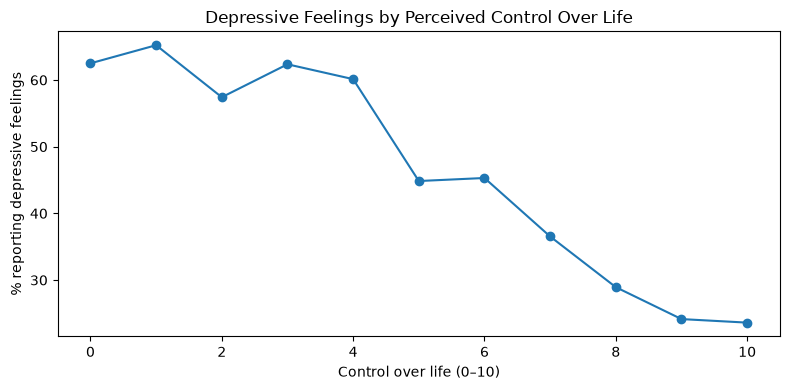

In [42]:
control_relation = (
    data.groupby("ctrlife")["depressive_feelings"]
    .mean() * 100
)

plt.figure(figsize=(8, 4))
control_relation.plot(marker="o")

plt.title("Depressive Feelings by Perceived Control Over Life")
plt.xlabel("Control over life (0–10)")
plt.ylabel("% reporting depressive feelings")

plt.tight_layout()
plt.show()

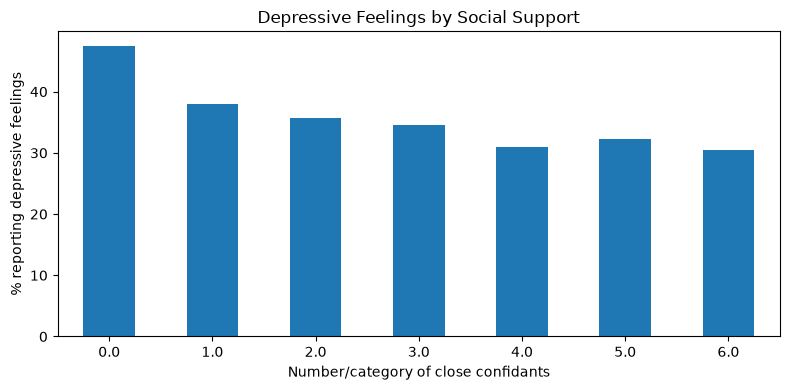

In [43]:
support_relation = (
    data.groupby("inprdsc")["depressive_feelings"]
    .mean() * 100
)

plt.figure(figsize=(8, 4))
support_relation.plot(kind="bar")

plt.title("Depressive Feelings by Social Support")
plt.xlabel("Number/category of close confidants")
plt.ylabel("% reporting depressive feelings")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [44]:
features = [
    "generation",
    "netustm",
    "slprl",
    "ctrlife",
    "health",
    "gndr",
    "uemp3m",
    "inprdsc"
]

X = data[features]
y = data["depressive_feelings"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print()
print("Missing values in predictors:")
print(X.isna().sum())

X shape: (14800, 8)
y shape: (14800,)

Missing values in predictors:
generation    0
netustm       0
slprl         0
ctrlife       0
health        0
gndr          0
uemp3m        0
inprdsc       0
dtype: int64


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print()
print("Training target proportions:")
print(y_train.value_counts(normalize=True))

print()
print("Test target proportions:")
print(y_test.value_counts(normalize=True))

Training set: (11840, 8)
Test set: (2960, 8)

Training target proportions:
depressive_feelings
0    0.656672
1    0.343328
Name: proportion, dtype: float64

Test target proportions:
depressive_feelings
0    0.656757
1    0.343243
Name: proportion, dtype: float64


In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "netustm",
    "slprl",
    "ctrlife",
    "health",
    "inprdsc"
]

categorical_features = [
    "generation",
    "gndr",
    "uemp3m"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['generation','netustm','slprl',...,'gndr','uemp3m','inprdsc']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remain

In [48]:
y_pred_log = logistic_model.predict(X_test)
y_prob_log = logistic_model.predict_proba(X_test)[:, 1]

In [49]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Classification report:")
print(classification_report(y_test, y_pred_log))

print("ROC-AUC:")
print(roc_auc_score(y_test, y_prob_log))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_log))

Classification report:
              precision    recall  f1-score   support

           0       0.80      0.71      0.75      1944
           1       0.54      0.65      0.59      1016

    accuracy                           0.69      2960
   macro avg       0.67      0.68      0.67      2960
weighted avg       0.71      0.69      0.70      2960

ROC-AUC:
0.7484228678591103
Confusion matrix:
[[1376  568]
 [ 351  665]]


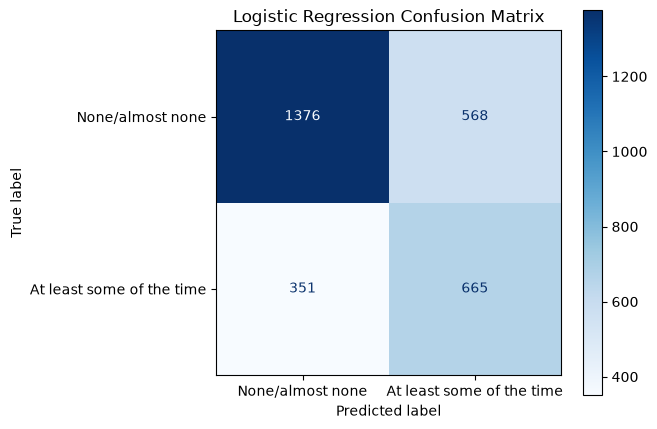

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    display_labels=[
        "None/almost none",
        "At least some of the time"
    ],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

In [51]:
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['generation','netustm','slprl',...,'gndr','uemp3m','inprdsc']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remain

In [53]:
y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [54]:
print("Classification report:")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:")
print(roc_auc_score(y_test, y_prob_rf))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.70      0.75      1944
           1       0.54      0.68      0.60      1016

    accuracy                           0.69      2960
   macro avg       0.67      0.69      0.68      2960
weighted avg       0.72      0.69      0.70      2960

ROC-AUC:
0.7516221930592009
Confusion matrix:
[[1357  587]
 [ 323  693]]


In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

comparison = pd.DataFrame({
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_log),
        "Precision": precision_score(y_test, y_pred_log),
        "Recall": recall_score(y_test, y_pred_log),
        "F1-score": f1_score(y_test, y_pred_log),
        "ROC-AUC": roc_auc_score(y_test, y_prob_log)
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-score": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
    }
}).T

comparison.round(3)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.690,0.539,0.655,0.591,0.748
Random Forest,0.693,0.541,0.682,0.604,0.752


In [56]:
feature_names = (
    random_forest
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    random_forest
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,num__slprl,0.379905
3,num__health,0.214372
2,num__ctrlife,0.162407
0,num__netustm,0.091228
4,num__inprdsc,0.065153
10,cat__uemp3m_2.0,0.018277
9,cat__uemp3m_1.0,0.016041
7,cat__gndr_1.0,0.014830
8,cat__gndr_2.0,0.014077
5,cat__generation_Gen Z,0.012098


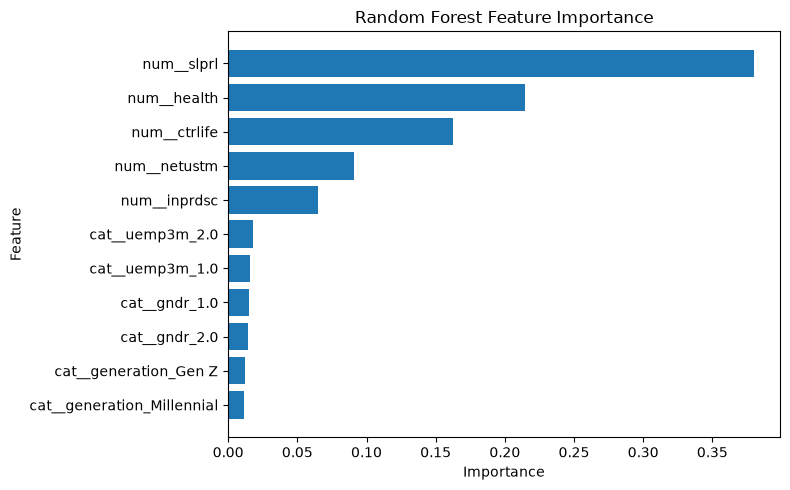

In [57]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [58]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    random_forest,
    "models/mental_health_model.joblib"
)

print("Model saved!")

Model saved!
